# Next Word Prediction Using LSTM

## Project Overview
This project implements a **Next Word Predictor** using Long Short-Term Memory (LSTM) neural networks for Natural Language Processing. The model predicts the next word in a sequence, which can be used for applications like:
- Text autocomplete
- Typing assistance
- Content generation

---
## 1. Import Required Libraries

We'll use TensorFlow/Keras for building the LSTM model and NumPy for numerical operations.

In [1]:
# pip install tensorflow
# pip install matplotlib

In [2]:
# Deep Learning Framework
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Utilities
import numpy as np
import matplotlib.pyplot as plt
import time

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


---
## 2. Data Preparation

In [3]:
# Load text corpus from file
with open('sample_text_corpus.txt', 'r', encoding='utf-8') as file:
    text_corpus = file.read()

print("Dataset loaded successfully!")
print(f"Total characters in corpus: {len(text_corpus):,}")
print(f"Total words (approx): {len(text_corpus.split()):,}")
print(f"Total lines in corpus: {len(text_corpus.split(chr(10))):,}")
print(f"\nFirst 500 characters preview:")
print("-" * 80)
print(text_corpus[:500] + "...")

Dataset loaded successfully!
Total characters in corpus: 17,090
Total words (approx): 2,294
Total lines in corpus: 98

First 500 characters preview:
--------------------------------------------------------------------------------
The Evolution of Artificial Intelligence and Machine Learning

Artificial intelligence has transformed the way we live and work in the modern world. From simple algorithms to complex neural networks, the journey of AI has been nothing short of remarkable. Machine learning, a subset of artificial intelligence, enables computers to learn from data without being explicitly programmed. This revolutionary approach has opened doors to countless applications across various industries.

In the field of ...


---
## 3. Text Preprocessing & Tokenization

In [4]:
# Initialize the Tokenizer
tokenizer = Tokenizer()

# Fit the tokenizer on the text data
tokenizer.fit_on_texts([text_corpus])

# Get vocabulary size
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token

print(f"Vocabulary Size: {vocab_size}")
print(f"\nFirst 20 words in vocabulary:")
for i, (word, idx) in enumerate(list(tokenizer.word_index.items())[:20]):
    print(f"{word}: {idx}", end="  ")
    if (i + 1) % 5 == 0:
        print()

Vocabulary Size: 954

First 20 words in vocabulary:
and: 1  the: 2  of: 3  to: 4  learning: 5  
ai: 6  in: 7  models: 8  data: 9  machine: 10  
for: 11  is: 12  has: 13  systems: 14  these: 15  
are: 16  can: 17  on: 18  from: 19  this: 20  


---
## 4. Creating Input Sequences

In [5]:
# Create input sequences
input_sequences = []

for sentence in text_corpus.split('\n'):
    # Convert sentence to token sequence
    tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]
    
    # Create n-gram sequences
    for i in range(1, len(tokenized_sentence)):
        n_gram_sequence = tokenized_sentence[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total sequences created: {len(input_sequences)}")
print(f"\nExample sequences (first 5):")
for i, seq in enumerate(input_sequences[:5]):
    print(f"Sequence {i+1}: {seq}")

Total sequences created: 2296

Example sequences (first 5):
Sequence 1: [2, 305]
Sequence 2: [2, 305, 3]
Sequence 3: [2, 305, 3, 31]
Sequence 4: [2, 305, 3, 31, 22]
Sequence 5: [2, 305, 3, 31, 22, 1]


### Padding Sequences


In [6]:
# Find maximum sequence length
max_sequence_length = max([len(seq) for seq in input_sequences])
print(f"Maximum sequence length: {max_sequence_length}")

# Pad sequences to ensure uniform length
padded_sequences = pad_sequences(input_sequences, maxlen=max_sequence_length, padding='pre')

print(f"Shape of padded sequences: {padded_sequences.shape}")
print(f"\nExample padded sequence:")
print(padded_sequences[10])

Maximum sequence length: 67
Shape of padded sequences: (2296, 67)

Example padded sequence:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0  31  22  13 168   2]


---
## 5. Preparing Training Data

In [7]:
# Split sequences into input (X) and output (y)
X = padded_sequences[:, :-1]  # All columns except last
y = padded_sequences[:, -1]   # Last column

print(f"Input shape (X): {X.shape}")
print(f"Output shape (y): {y.shape}")

# Convert output to categorical (one-hot encoding)
y = to_categorical(y, num_classes=vocab_size)

print(f"Output shape after one-hot encoding: {y.shape}")
print(f"\nDataset ready for training!")

Input shape (X): (2296, 66)
Output shape (y): (2296,)
Output shape after one-hot encoding: (2296, 954)

Dataset ready for training!


---
## 6. Building the LSTM Model


In [8]:
# Build the Sequential model
model = Sequential([
    # Embedding layer: converts word indices to dense vectors
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_sequence_length-1),
    
    # First LSTM layer with return sequences for stacking
    LSTM(units=150, return_sequences=True),
    Dropout(0.2),  # Dropout for regularization
    
    # Second LSTM layer
    LSTM(units=150),
    Dropout(0.2),
    
    # Output layer: predicts next word probability
    Dense(units=vocab_size, activation='softmax')
])

# Build the model explicitly to show proper parameter counts
model.build(input_shape=(None, max_sequence_length-1))

# Display model architecture
model.summary()

c:\Users\arpit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 66, 100)        │        95,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 66, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 66, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 954)            │       144,054 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,654 (2.18 MB)

 Trainable params: 570,654 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

---
## 7. Model Compilation



In [9]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',  # For multi-class classification
    optimizer='adam',                 # Adam optimizer for faster convergence
    metrics=['accuracy']              # Track accuracy during training
)

print("Model compiled successfully!")

Model compiled successfully!


---
## 8. Model Training


In [10]:
# Define callbacks
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='loss')

# Train the model
history = model.fit(
    X, y,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping, model_checkpoint]
)

print("\nTraining completed!")

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.0294 - loss: 6.6442

72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.0370 - loss: 6.5080
Epoch 2/100
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.0460 - loss: 6.1593

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.0462 - loss: 6.1310
Epoch 3/100
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0387 - loss: 6.0260

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.0449 - loss: 6.0782
Epoch 4/100
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.0403 - loss: 5.9493

72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.0470 - loss: 5.9531
Epoch 5/100
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.0357 - loss: 5.7954

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.9286 - loss: 0.4860
Epoch 97/100
Epoch 97/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9412 - loss: 0.4446

72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9386 - loss: 0.4587
Epoch 98/100
Epoch 98/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9380 - loss: 0.4335

72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.9399 - loss: 0.4377
Epoch 99/100
Epoch 99/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9445 - loss: 0.4127

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9390 - loss: 0.4313
Epoch 100/100
Epoch 100/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9473 - loss: 0.4134

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9460 - loss: 0.4158

Training completed!

Training completed!


---
## 9. Training History Visualization

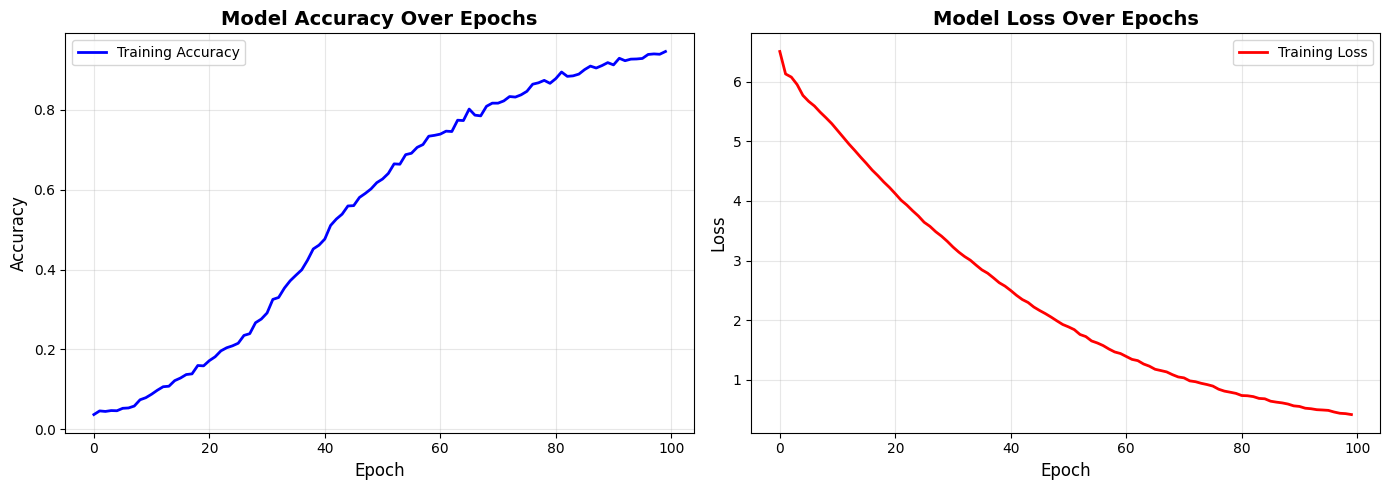


Final Training Accuracy: 0.9460 (94.60%)
Final Training Loss: 0.4158


In [11]:
# Plot training history
plt.figure(figsize=(14, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_accuracy = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]
print(f"\nFinal Training Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Final Training Loss: {final_loss:.4f}")

---
## 10. Text Generation Function

In [12]:
def predict_next_words(seed_text, num_words=10):
    """
    Predicts the next 'num_words' words based on the seed text.
    
    Args:
        seed_text (str): Initial text to start prediction
        num_words (int): Number of words to predict
    
    Returns:
        str: Generated text
    """
    generated_text = seed_text
    
    for _ in range(num_words):
        # Tokenize the current text
        token_text = tokenizer.texts_to_sequences([generated_text])[0]
        
        # Pad the sequence
        padded_token_text = pad_sequences([token_text], maxlen=max_sequence_length-1, padding='pre')
        
        # Predict the next word
        predictions = model.predict(padded_token_text, verbose=0)
        predicted_index = np.argmax(predictions)
        
        # Find the word corresponding to the predicted index
        predicted_word = None
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break
        
        # If word found, append to generated text
        if predicted_word:
            generated_text += " " + predicted_word
        else:
            break
    
    return generated_text

print("Text generation function created successfully!")

Text generation function created successfully!


---
## 11. Testing the Model - Next Word Prediction


In [13]:
# Test cases - AI/ML related seed texts
test_cases = [
    "artificial intelligence",
    "machine learning",
    "neural networks",
    "deep learning",
    "the model"
]

print("=" * 80)
print("NEXT WORD PREDICTION RESULTS")
print("=" * 80)

for seed in test_cases:
    result = predict_next_words(seed, num_words=10)
    print(f"\nSeed Text: '{seed}'")
    print(f"Generated: {result}")
    print("-" * 80)

NEXT WORD PREDICTION RESULTS

Seed Text: 'artificial intelligence'
Generated: artificial intelligence has transformed the way we live and work in the
--------------------------------------------------------------------------------

Seed Text: 'artificial intelligence'
Generated: artificial intelligence has transformed the way we live and work in the
--------------------------------------------------------------------------------

Seed Text: 'machine learning'
Generated: machine learning operations or mlops focuses on deploying and maintaining models in
--------------------------------------------------------------------------------

Seed Text: 'machine learning'
Generated: machine learning operations or mlops focuses on deploying and maintaining models in
--------------------------------------------------------------------------------

Seed Text: 'neural networks'
Generated: neural networks have inspired by the structure of the human brain these
----------------------------------------

---
## 13. Model Evaluation & Insights

In [14]:
# Model summary statistics
print("="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(f"\n📊 Model Architecture:")
print(f"   - Total Parameters: {model.count_params():,}")
print(f"   - Vocabulary Size: {vocab_size}")
print(f"   - Embedding Dimension: 100")
print(f"   - LSTM Units per layer: 150")
print(f"   - Maximum Sequence Length: {max_sequence_length}")

print(f"\n📈 Training Results:")
print(f"   - Final Accuracy: {final_accuracy*100:.2f}%")
print(f"   - Final Loss: {final_loss:.4f}")
print(f"   - Total Epochs Trained: {len(history.history['accuracy'])}")

print(f"\n📝 Dataset Statistics:")
print(f"   - Total Training Sequences: {len(X):,}")
print(f"   - Total Unique Words: {vocab_size - 1}")
print(f"   - Average Sequence Length: {np.mean([len(seq) for seq in input_sequences]):.2f}")

print(f"\n⚙️ Optimizer:")
print(f"   - Algorithm: Adam")
print(f"   - Benefits: Adaptive learning rate, faster convergence")

print("\n" + "="*80)

MODEL PERFORMANCE SUMMARY

📊 Model Architecture:
   - Total Parameters: 570,654
   - Vocabulary Size: 954
   - Embedding Dimension: 100
   - LSTM Units per layer: 150
   - Maximum Sequence Length: 67

📈 Training Results:
   - Final Accuracy: 94.60%
   - Final Loss: 0.4158
   - Total Epochs Trained: 100

📝 Dataset Statistics:
   - Total Training Sequences: 2,296
   - Total Unique Words: 953
   - Average Sequence Length: 25.98

⚙️ Optimizer:
   - Algorithm: Adam
   - Benefits: Adaptive learning rate, faster convergence



---
## 14. Saving the Model

In [15]:
import pickle

# Save the model
model.save('next_word_predictor_lstm.h5')
print("✅ Model saved as 'next_word_predictor_lstm.h5'")

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved as 'tokenizer.pkl'")

# Save model configuration
config = {
    'vocab_size': vocab_size,
    'max_sequence_length': max_sequence_length,
    'embedding_dim': 100,
    'lstm_units': 150,
    'final_accuracy': float(final_accuracy),
    'final_loss': float(final_loss)
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✅ Model configuration saved as 'model_config.pkl'")

✅ Model saved as 'next_word_predictor_lstm.h5'
✅ Tokenizer saved as 'tokenizer.pkl'
✅ Model configuration saved as 'model_config.pkl'
